 In this notebook, I will create a workflow to load the data, change the units, group the data by well, and export the group data. After I test out functions for ploting

In [1]:
#basics
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("src")   # VERY IMPORTANT

In [3]:
file_path = ( "../0_Volve_dataset/5_Production_data/Volve_production_data.xlsx")
production_df=pd.read_excel(file_path,index_col='DATEPRD', parse_dates=True) 

production_df

,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,96.87589,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-14,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,%,0.07776,0.22879,0.01862,0.0,0.0,0.0,NaN,production,OP
2016-09-15,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,%,0.08545,0.22914,0.00631,0.0,0.0,0.0,NaN,production,OP
2016-09-16,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,NaN,...,%,0.08544,0.22896,0.01181,0.0,0.0,0.0,NaN,production,OP


In [4]:
production_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15634 entries, 2014-04-07 to 2016-09-18
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   WELL_BORE_CODE            15634 non-null  object 
 1   NPD_WELL_BORE_CODE        15634 non-null  int64  
 2   NPD_WELL_BORE_NAME        15634 non-null  object 
 3   NPD_FIELD_CODE            15634 non-null  int64  
 4   NPD_FIELD_NAME            15634 non-null  object 
 5   NPD_FACILITY_CODE         15634 non-null  int64  
 6   NPD_FACILITY_NAME         15634 non-null  object 
 7   ON_STREAM_HRS             15349 non-null  float64
 8   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64
 9   AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64
 10  AVG_DP_TUBING             8980 non-null   float64
 11  AVG_ANNULUS_PRESS         7890 non-null   float64
 12  AVG_CHOKE_SIZE_P          8919 non-null   float64
 13  AVG_CHOKE_UOM             9161 non-null   ob

#### Meaning of channels

| Header                     | Meaning                                                                                                                   |
| -------------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| `DATEPRD`                  | Production date. One row is usually one well on one day.                                                                  |
| `WELL_BORE_CODE`           | Internal wellbore identifier/code.                                                                                        |
| `NPD_WELL_BORE_CODE`       | Norwegian Petroleum Directorate wellbore code. Unique official wellbore ID.                                               |
| `NPD_WELL_BORE_NAME`       | Wellbore name, for example something like `15/9-F-1 C`. This is the main well name you usually group by.                  |
| `NPD_FIELD_CODE`           | Official field code.                                                                                                      |
| `NPD_FIELD_NAME`           | Field name. In this case, usually `VOLVE`.                                                                                |
| `NPD_FACILITY_CODE`        | Official facility code.                                                                                                   |
| `NPD_FACILITY_NAME`        | Facility name/platform associated with the well.                                                                          |
| `ON_STREAM_HRS`            | Number of hours the well was producing or injecting that day. Max is usually 24.                                          |
| `AVG_DOWNHOLE_PRESSURE`    | Average pressure measured downhole, near the reservoir/wellbore. Important for reservoir/well performance.                |
| `AVG_DOWNHOLE_TEMPERATURE` | Average downhole temperature.                                                                                             |
| `AVG_DP_TUBING`            | Average pressure differential across the tubing. Usually related to pressure loss from bottomhole to wellhead.            |
| `AVG_ANNULUS_PRESS`        | Average annulus pressure. Annulus is the space between tubing and casing.                                                 |
| `AVG_CHOKE_SIZE_P`         | Average choke opening percentage. This controls how much the well is allowed to flow. Very important for production rate. |
| `AVG_CHOKE_UOM`            | Unit of measurement for choke size, often `%`.                                                                            |
| `AVG_WHP_P`                | Average wellhead pressure. Pressure at the surface wellhead.                                                              |
| `AVG_WHT_P`                | Average wellhead temperature. Temperature at the surface wellhead.                                                        |
| `DP_CHOKE_SIZE`            | Pressure drop across the choke. This can be important for flow-rate modeling.                                             |
| `BORE_OIL_VOL`             | Oil volume produced that day. This is one possible ML target.                                                             |
| `BORE_GAS_VOL`             | Gas volume produced that day. Another possible ML target.                                                                 |
| `BORE_WAT_VOL`             | Water volume produced that day. Another possible ML target.                                                               |
| `BORE_WI_VOL`              | Water injection volume. Mostly relevant for injector wells, not oil producers.                                            |
| `FLOW_KIND`                | Type of flow record, for example production or injection.                                                                 |
| `WELL_TYPE`                | Type of well, for example oil producer or water injector.                                                                 |


In [5]:
# find the unique number of wells names
unique_wellnames=production_df["NPD_WELL_BORE_NAME"].unique()
unique_wellnames

array(['15/9-F-1 C', '15/9-F-11', '15/9-F-12', '15/9-F-14', '15/9-F-15 D',
       '15/9-F-4', '15/9-F-5'], dtype=object)

In [6]:
# find column name list
column_names=production_df.columns
column_names

Index(['WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME',
       'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE',
       'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE',
       'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS',
       'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'AVG_WHP_P', 'AVG_WHT_P',
       'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL',
       'BORE_WI_VOL', 'FLOW_KIND', 'WELL_TYPE'],
      dtype='object')

## Create new dataframe for wells and change units and plot


In [7]:
# change unit from metric to field units
from basic_helper_functions import change_metric_to_field
df_field=change_metric_to_field(production_df)

In [8]:
# drop columns u dont need
production_df = production_df.drop(columns=[
    col for col in [
        "WELL_BORE_CODE","NPD_WELL_BORE_CODE", "NPD_FIELD_CODE","NPD_FIELD_NAME","NPD_FACILITY_CODE","NPD_FACILITY_NAME","NPD_FIELD_CODE",'BORE_WI_VOL', 'FLOW_KIND',
        'WELL_TYPE', 'AVG_DOWNHOLE_PRESSURE_PSI','AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI','AVG_ANNULUS_PRESS_PSI','AVG_WHP_P_PSI', 'AVG_WHT_P'
        ] if col in production_df.columns
    ])

In [9]:
# make new dfs
wells = {}

# 2. Loop through your groupby object
i = 1
for name, df in df_field.groupby("NPD_WELL_BORE_NAME"):
    # This creates keys like 'df_1', 'df_2', etc., and assigns the DataFrame to them
    wells[f"df_{i}"] = df
    i += 1

In [10]:
# assign the  dictionary dfs to a variable
df_1=wells["df_1"]
df_2=wells["df_2"]
df_3=wells["df_3"]
df_4=wells["df_4"]
df_5=wells["df_5"]
df_6=wells["df_6"]
df_7=wells["df_7"]

In [11]:
#explicitly sets the time frequency of  DatetimeIndex to "Daily" (D).
df_1.asfreq('D')
df_2.asfreq('D')
df_3.asfreq('D')
df_4.asfreq('D')
df_5.asfreq('D')
df_6.asfreq('D')
df_7.asfreq('D')


,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,...,AVG_ANNULUS_PRESS_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,BORE_WI_VOL_STB_D,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF_STB,WCUT
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2007-09-01,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-09-02,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-09-03,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-09-04,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-09-05,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-14,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.636088,%,...,3.955476,0.270061,1.127815,NaN,32.411822,0.0,0.0,0.0,NaN,NaN
2016-09-15,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.670794,%,...,4.160560,0.091519,1.239350,NaN,32.412452,0.0,0.0,0.0,NaN,NaN
2016-09-16,NO 15/9-F-5 AH,5769,15/9-F-5,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.664393,%,...,4.148667,0.171290,1.239205,NaN,32.412128,0.0,0.0,0.0,NaN,NaN


## Export out the dataframes

In [12]:
df_1.to_csv("processed_inputs/df1.csv", index=True)
df_2.to_csv("processed_inputs/df2.csv", index=True)
df_3.to_csv("processed_inputs/df3.csv", index=True)
df_4.to_csv("processed_inputs/df4.csv", index=True)
df_5.to_csv("processed_inputs/df5.csv", index=True)
df_6.to_csv("processed_inputs/df6.csv", index=True)
df_7.to_csv("processed_inputs/df7.csv", index=True)

## Making and testing the plots

In [13]:
# find the new list of columns names 
df_1.columns

Index(['WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME',
       'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE',
       'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P',
       'AVG_CHOKE_UOM', 'FLOW_KIND', 'WELL_TYPE', 'AVG_DOWNHOLE_PRESSURE_PSI',
       'AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI',
       'AVG_ANNULUS_PRESS_PSI', 'DP_CHOKE_SIZE_PSI', 'AVG_WHP_P_PSI',
       'BORE_WI_VOL_STB_D', 'AVG_WHT_P', 'BORE_OIL_VOL_STB_D',
       'BORE_GAS_VOL_MSCF_D', 'BORE_WAT_VOL_STB_D', 'GOR_MSCF_STB', 'WCUT'],
      dtype='object')

In [14]:
# Make plots
# select target variable feature
target_col=['BORE_OIL_VOL_STB_D', 'BORE_GAS_VOL_MSCF_D','BORE_WAT_VOL_STB_D']
predictor_num_col=['ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P',
       'DP_CHOKE_SIZE_PSI',
      'AVG_DOWNHOLE_PRESSURE_PSI', 'AVG_DOWNHOLE_TEMPERATURE_F',
       'AVG_DP_TUBING_PSI', 'AVG_ANNULUS_PRESS_PSI', 'AVG_WHP_P_PSI',
       'BORE_WI_VOL_STB_D', 'AVG_WHT_P', 'GOR_MSCF_STB', 'WCUT']
predictor_cat_cols=['FLOW_KIND', 'WELL_TYPE']

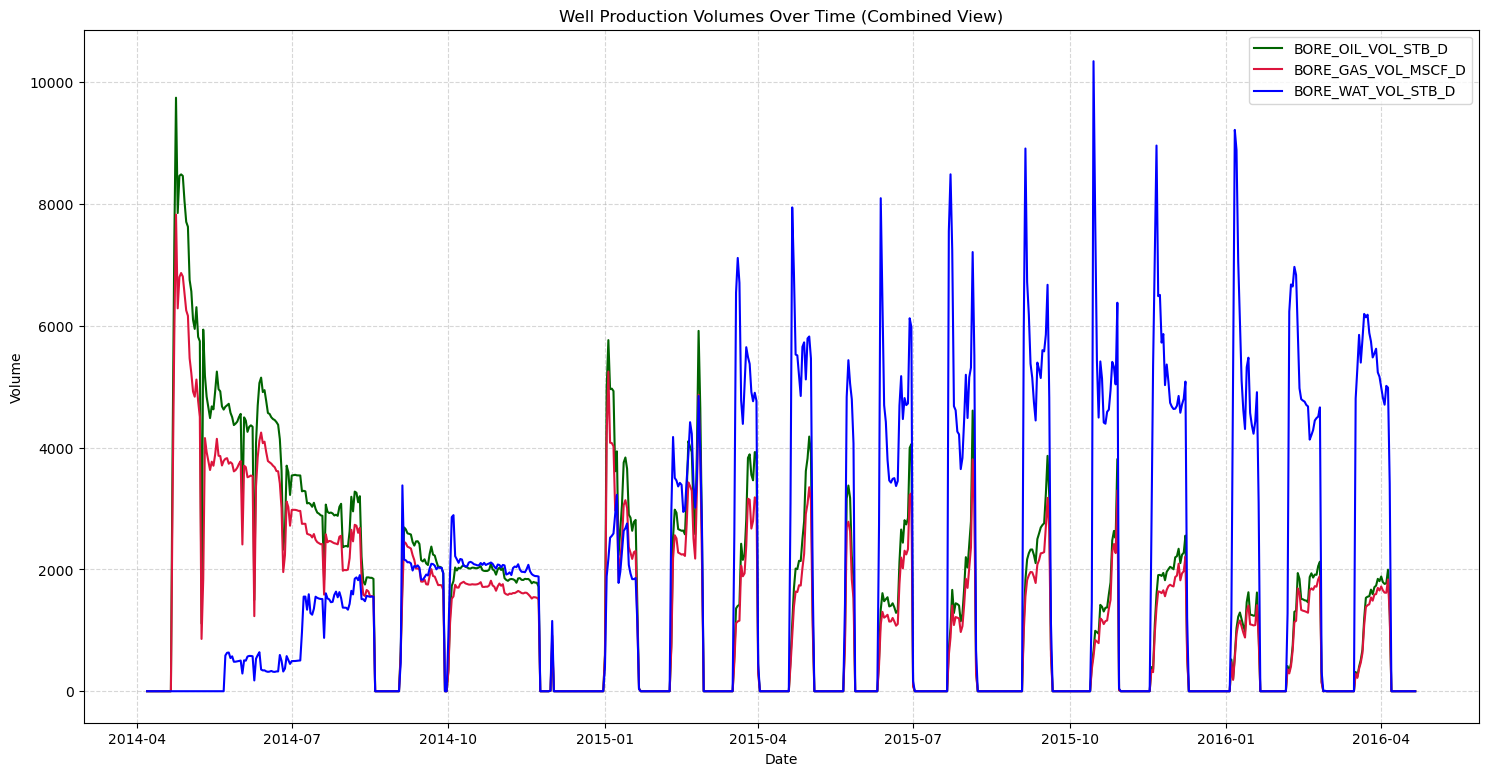

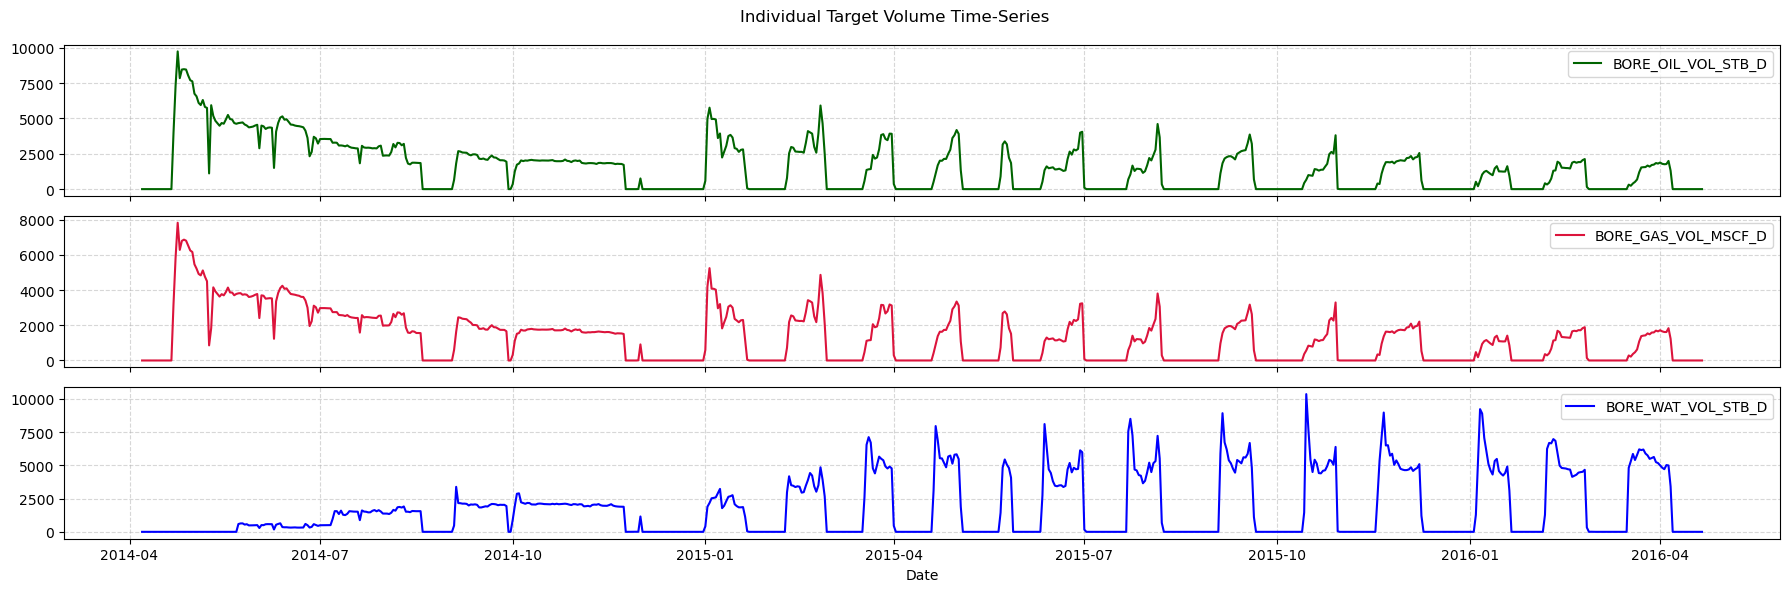

In [15]:
from basic_helper_functions import combined_target_plot
from basic_helper_functions import seperate_target_plot
combined_target_plot(df_1[target_col])
seperate_target_plot(df_1[target_col])

In [16]:
df_1[predictor_num_col].columns

Index(['ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P', 'DP_CHOKE_SIZE_PSI',
       'AVG_DOWNHOLE_PRESSURE_PSI', 'AVG_DOWNHOLE_TEMPERATURE_F',
       'AVG_DP_TUBING_PSI', 'AVG_ANNULUS_PRESS_PSI', 'AVG_WHP_P_PSI',
       'BORE_WI_VOL_STB_D', 'AVG_WHT_P', 'GOR_MSCF_STB', 'WCUT'],
      dtype='object')

In [17]:
df_1

,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,...,AVG_ANNULUS_PRESS_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,BORE_WI_VOL_STB_D,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF_STB,WCUT
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.000000,%,...,0.0,0.000000,0.000000,NaN,32.000000,0.0,0.0,0.0,NaN,NaN
2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,1.003059,%,...,0.0,0.000000,0.000000,NaN,32.000000,0.0,0.0,0.0,NaN,NaN
2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.979008,%,...,0.0,0.000000,0.000000,NaN,32.000000,0.0,0.0,0.0,NaN,NaN
2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.545759,%,...,0.0,0.000000,0.000000,NaN,32.000000,0.0,0.0,0.0,NaN,NaN
2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,1.215987,%,...,0.0,479.668948,480.045032,NaN,50.863856,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.000000,%,...,NaN,38.366612,94.247723,NaN,49.644446,0.0,0.0,0.0,NaN,NaN
2016-04-18,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.000000,%,...,NaN,59.755656,198.904678,NaN,53.136032,0.0,0.0,0.0,NaN,NaN
2016-04-19,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.265188,%,...,NaN,27.068152,124.381543,NaN,50.214308,0.0,0.0,0.0,NaN,NaN


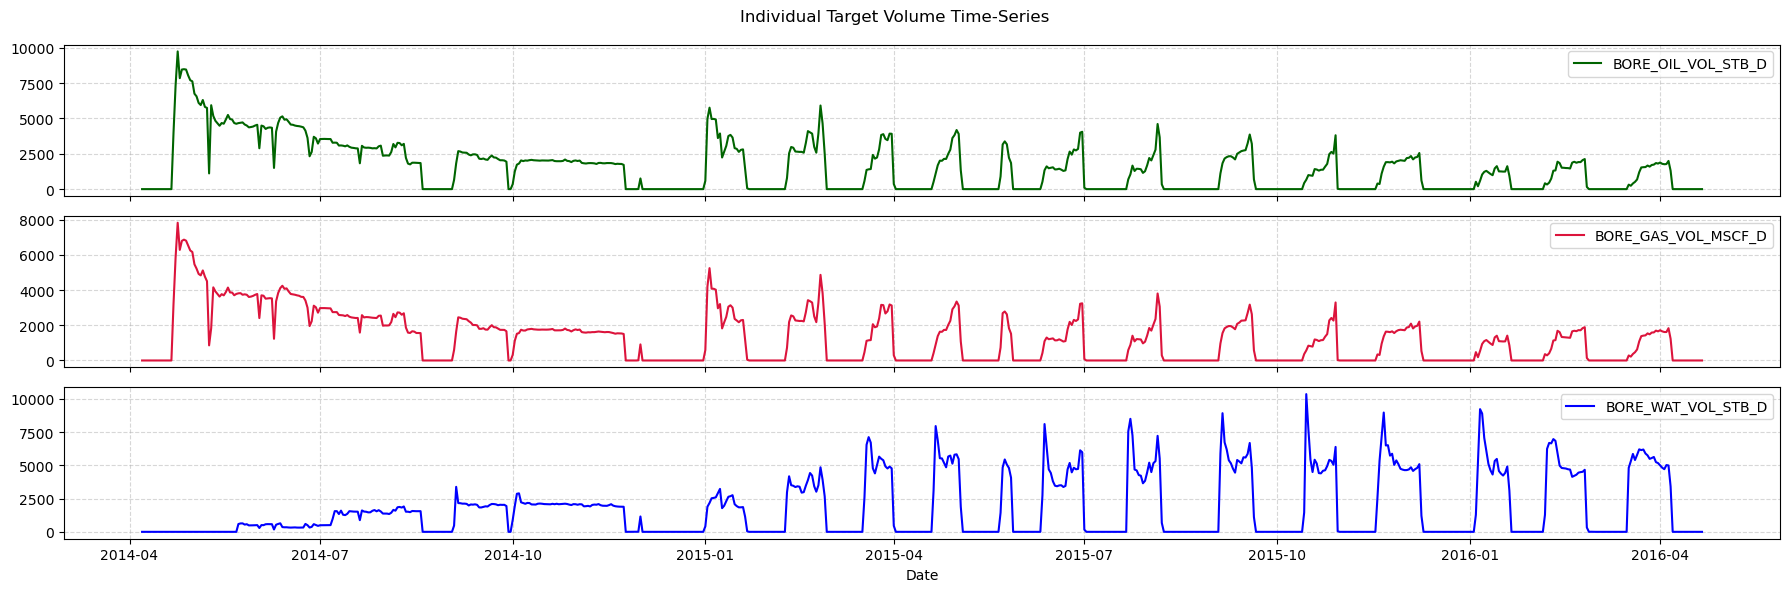

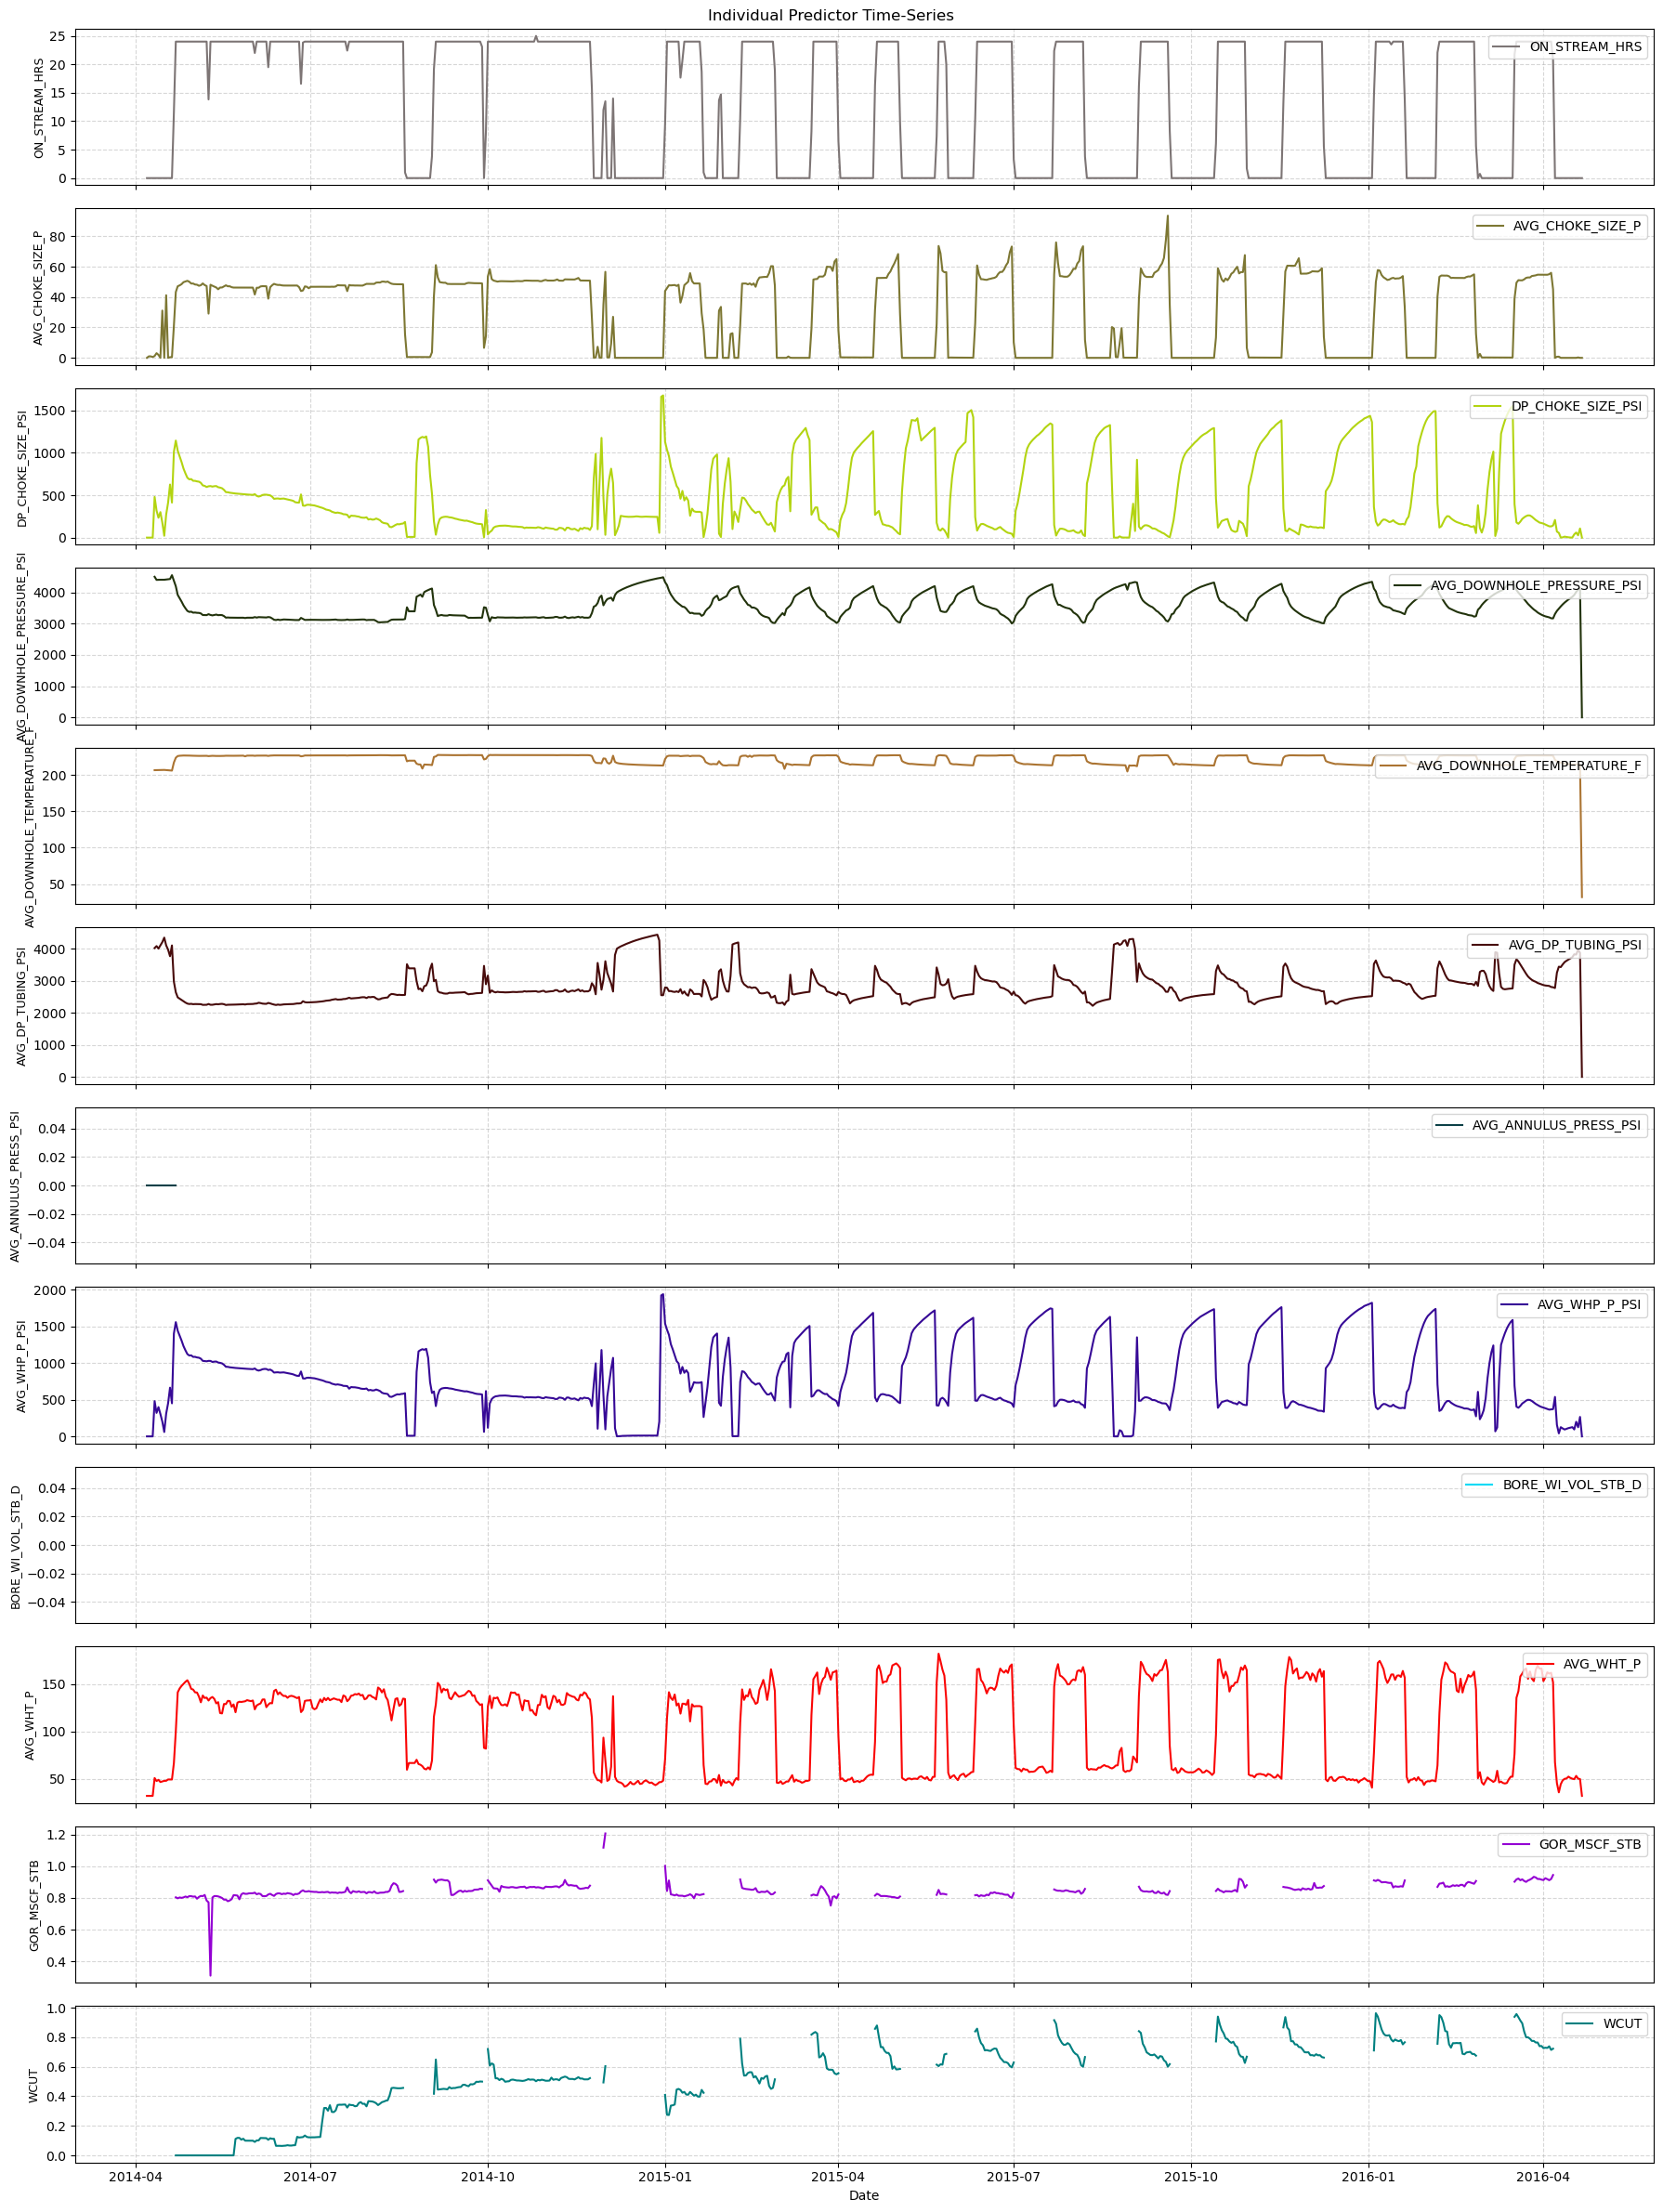

In [18]:
from basic_helper_functions import combined_predictor_plot
from basic_helper_functions import seperate_predictor_plot
seperate_target_plot(df_1[target_col])
seperate_predictor_plot(df_1[predictor_num_col])
